## seq2seq으로 번역기 만들기 (한 -> 영)

In [ ]:
!sudo apt update
!sudo apt-get install -y fonts-nanum
!pip install sentencepiece

한국어를 지원하는 폰트로 변경

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


### 데이터 준비하기

프로젝트에 사용될 라이브러리 import

In [2]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.7.1+cu118


데이터 다운로드

In [3]:
!wget https://github.com/jungyeul/korean-parallel-corpora/raw/refs/heads/master/korean-english-news-v1/korean-english-park.train.tar.gz
!tar -zxvf korean-english-park.train.tar.gz

--2026-05-14 07:26:48--  https://github.com/jungyeul/korean-parallel-corpora/raw/refs/heads/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/refs/heads/master/korean-english-news-v1/korean-english-park.train.tar.gz [following]
--2026-05-14 07:26:49--  https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/refs/heads/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8718893 (8.3M) [application/octet-stream]
Saving to: ‘korean-eng

In [3]:
import pandas as pd

# 1. 각 파일을 읽어서 리스트로 저장
with open('korean-english-park.train.en', 'r', encoding='utf-8') as f:
    eng_data = f.read().splitlines()

with open('korean-english-park.train.ko', 'r', encoding='utf-8') as f:
    kor_data = f.read().splitlines()

# 2. 두 리스트를 딕셔너리 형태로 묶어서 데이터프레임 생성
df = pd.DataFrame({
    'eng': eng_data,
    'kor': kor_data
})

# 3. 결과 확인
print(f"전체 데이터 개수: {len(df)}")
df.head()

전체 데이터 개수: 94123


,eng,kor
0,"Much of personal computing is about ""can you t...","개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?"""
1,so a mention a few weeks ago about a rechargea...,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...
2,"Like all optical mice, But it also doesn't nee...",그러나 이것은 또한 책상도 필요로 하지 않는다.
3,uses gyroscopic sensors to control the cursor ...,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분..."
4,Intelligence officials have revealed a spate o...,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...


In [4]:
df.info

<bound method DataFrame.info of                                                      eng  \
0      Much of personal computing is about "can you t...   
1      so a mention a few weeks ago about a rechargea...   
2      Like all optical mice, But it also doesn't nee...   
3      uses gyroscopic sensors to control the cursor ...   
4      Intelligence officials have revealed a spate o...   
...                                                  ...   
94118  ””We are hoping to seize material evidence to ...   
94119  ” On Monday, police secured statements from si...   
94120  But the lack of material evidence is making it...   
94121         Kim and his son both deny the allegations.   
94122  Police are planning to seek arrest warrants fo...   

                                                     kor  
0                   개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"  
1      모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...  
2                             그러나 이것은 또한 책상도 필요로 하지 않는다.  
3      79.9

In [5]:
print(df['eng'].nunique())
print(df['kor'].nunique())

75598
77591


#### 중복 데이터 제거

In [6]:
# inplace=True 를 설정하면 DataFrame 타입 값을 return 하지 않고 data 내부를 직접적으로 바꿉니다
df.drop_duplicates(subset = ['kor'], inplace=True)
print('전체 샘플수 :', (len(df)))

전체 샘플수 : 77591


In [7]:
print(df.isnull().sum())

eng    0
kor    0
dtype: int64


### 데이터 전처리 : 정제하기

In [10]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

print("슝~")

슝~


In [11]:
# 상위 3만 개만 사용
# df = df[:30000]

df["eng"] = df["eng"].apply(preprocess_sentence)
df["kor"] = df["kor"].apply(lambda x: preprocess_sentence(x))

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77591 entries, 0 to 94122
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   eng     77591 non-null  object
 1   kor     77591 non-null  object
dtypes: object(2)
memory usage: 1.8+ MB


영어의 최소 길이 : 0
영어의 최대 길이 : 99
영어의 평균 길이 : 24.93737675761364
한국어의 최소 길이 : 0
한국어의 최대 길이 : 74
한국어의 평균 길이 : 16.633875062829453


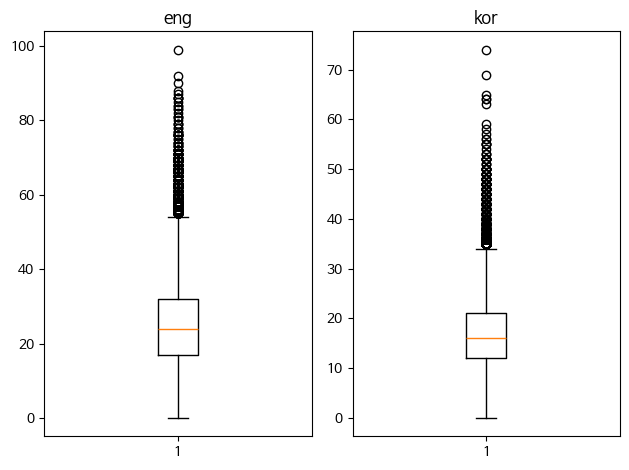

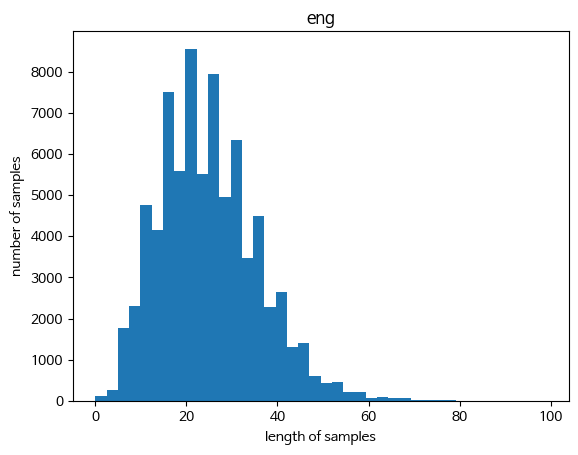

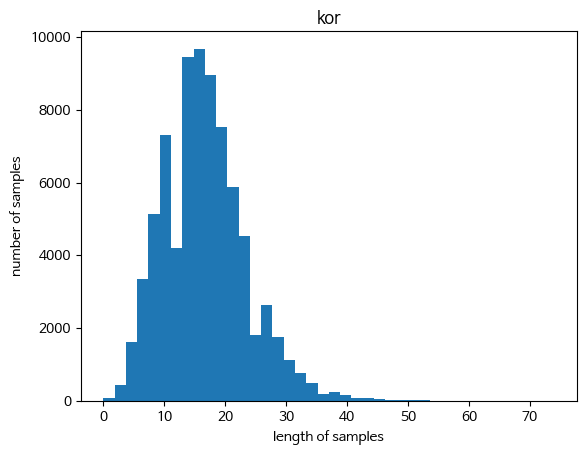

In [12]:
# 길이 분포 출력
import matplotlib.pyplot as plt

eng_len = [len(s.split()) for s in df['eng']]
kor_len = [len(s.split()) for s in df['kor']]

print('영어의 최소 길이 : {}'.format(np.min(eng_len)))
print('영어의 최대 길이 : {}'.format(np.max(eng_len)))
print('영어의 평균 길이 : {}'.format(np.mean(eng_len)))
print('한국어의 최소 길이 : {}'.format(np.min(kor_len)))
print('한국어의 최대 길이 : {}'.format(np.max(kor_len)))
print('한국어의 평균 길이 : {}'.format(np.mean(kor_len)))

plt.subplot(1,2,1)
plt.boxplot(eng_len)
plt.title('eng')
plt.subplot(1,2,2)
plt.boxplot(kor_len)
plt.title('kor')
plt.tight_layout()
plt.show()

plt.title('eng')
plt.hist(eng_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

plt.title('kor')
plt.hist(kor_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [17]:
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df["kor"].to_csv("kor_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, kor_corpus.txt")

파일 저장 완료: eng_corpus.txt, kor_corpus.txt


### 데이터 전처리 : 토큰화

In [18]:
!pip install konlpy 
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git 
%cd Mecab-ko-for-Google-Colab/ 
!bash install_mecab-ko_on_colab_light_220429.sh

Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 138 (delta 26), reused 22 (delta 8), pack-reused 91 (from 1)
Receiving objects: 100% (138/138), 1.72 MiB | 8.48 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/home/jovyan/work/AIFFEL_quest_rs/GoingDeeper/Quest_05/Mecab-ko-for-Google-Colab/Mecab-ko-for-Google-Colab
install_mecab-ko_on_colab_light_220429.sh: line 4: cd: /content: No such file or directory
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-05-14 09:38:26--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 13.200.41.136, 13.200.41.135, 13.200.41.134, ...
Connecting to bitbucket.org (bitbucket.org)|13.200.41.136|:443... connected.
HTTP request sent, aw

In [22]:
from konlpy.tag import Mecab

mecab = Mecab()

def tokenize_korean(text):
    tokens = mecab.morphs(str(text))
    return ' '.join(tokens)

with open("kor_corpus.txt", "w", encoding="utf-8") as f:
    for text in df["kor"]:
        tokenized = tokenize_korean(text)
        f.write(tokenized + "\n")

vocab_size = 10000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "kor_corpus.txt",
    model_prefix = "encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: kor_corpus.txt
  input_format: 
  model_prefix: encoder_spm
  model_type: UNIGRAM
  vocab_size: 10000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  

True

In [23]:
eng_sample = df["eng"][0]
kor_sample = df["kor"][0]
print(eng_sample)
print(kor_sample)

much of personal computing is about can you top this ?
개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?


In [24]:
enc_token = encoder_tokenizer.encode(kor_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

[1,
 1030,
 364,
 840,
 290,
 294,
 1264,
 76,
 209,
 997,
 5,
 478,
 237,
 67,
 2777,
 279,
 38,
 19,
 4033,
 1266,
 4,
 9985,
 2]

In [25]:
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?'

In [26]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['kor']
        trg_text = self.data.iloc[idx]['eng']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [27]:
train_ratio = 1.0  # val dataset 없이 진행
MAX_LEN = 40 # 임의의 값
BATCH_SIZE = 64

train_data = df.sample(frac=train_ratio, random_state=42)
valid_data = df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validation_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [28]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 40]) torch.Size([64, 40]) torch.Size([64, 40])


### GRU Encoder-Decoder 구조 설계

### Bahdanau Attention

In [29]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)
        # 세 개의 선형 변환 레이어를 정의
          # W1: encoder outputs를 변환
          # W2: decoder hidden state를 변환
          # v: energy를 attention score로 변환
    
    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        # encoder_outputs와 hidden state 각각을 선형 변환
        # 두 변환된 텐서를 더한 후 tanh 활성화 함수 적용
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)
        #  energy를 v 레이어로 변환하여 각 위치의 attention 점수 계산
        # softmax를 적용하여 모든 위치의 attention 가중치 합이 1이 되도록 정규화    
        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

Encoder

In [30]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

Decoder

In [31]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

seq2seq(with attention)

In [32]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [34]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [35]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(10000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(10000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=10000, bias=True)
  )
)


In [36]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


#### Train step 구현

In [37]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


In [38]:
%%time

EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1: 100%|██████████| 1213/1213 [04:28<00:00,  4.51it/s, loss=4.05]


Epoch 1/10, Train Loss: 4.8502


Epoch 2: 100%|██████████| 1213/1213 [04:31<00:00,  4.47it/s, loss=3.52]


Epoch 2/10, Train Loss: 3.7431


Epoch 3: 100%|██████████| 1213/1213 [04:32<00:00,  4.46it/s, loss=3.37]


...

Epoch 8/10, Train Loss: 1.8895


Epoch 9: 100%|██████████| 1213/1213 [04:31<00:00,  4.47it/s, loss=2.05]


Epoch 9/10, Train Loss: 1.7652


Epoch 10: 100%|██████████| 1213/1213 [04:30<00:00,  4.48it/s, loss=1.83]

Epoch 10/10, Train Loss: 1.6604
CPU times: user 41min 49s, sys: 3min 37s, total: 45min 27s
Wall time: 45min 12s


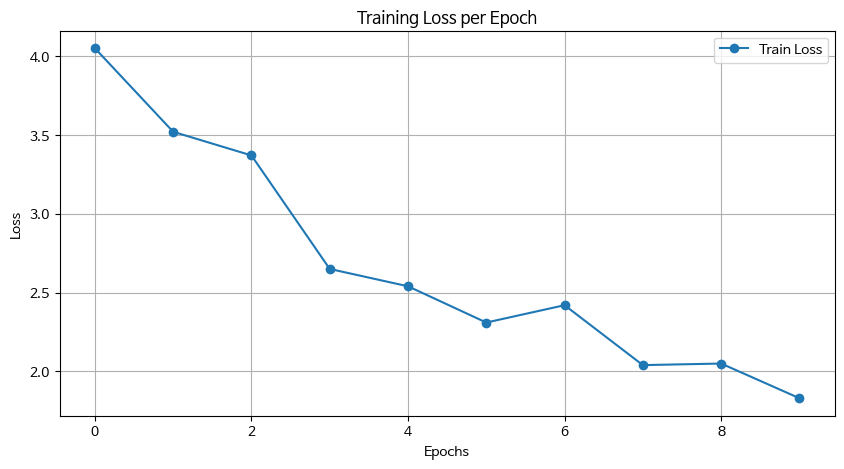

In [54]:
import matplotlib.pyplot as plt

train_losses = [4.05, 3.52, 3.37, 2.65, 2.54, 2.31, 2.42, 2.04, 2.05, 1.83]
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')

plt.title('Training Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True) # 격자를 추가하면 수치 확인이 편합니다.
plt.show()

#### 번역 성능 평가

In [39]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [40]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [41]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

Input: 오바마는 대통령이다 .
Predicted translation: ['obama', 's', 'president', 'has', 'been', 'chill', 'ed', 'by', 'president', 'obama', '.', '']


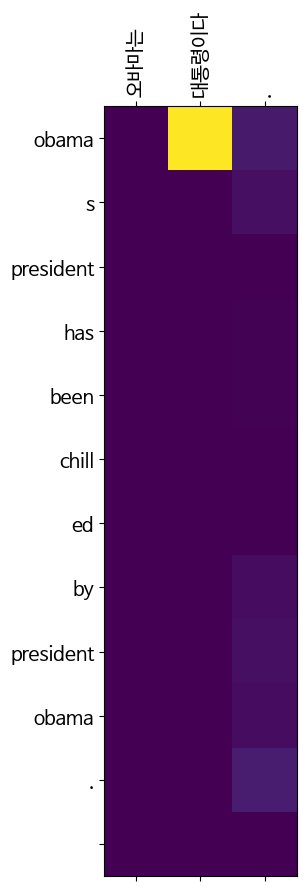

In [45]:
translate("오바마는 대통령이다.", model, encoder_tokenizer, decoder_tokenizer, max_len=40)

Input: 시민들은 도시 속에 산다 .
Predicted translation: ['citizens', 'were', 'in', 'mountain', 'cities', '']


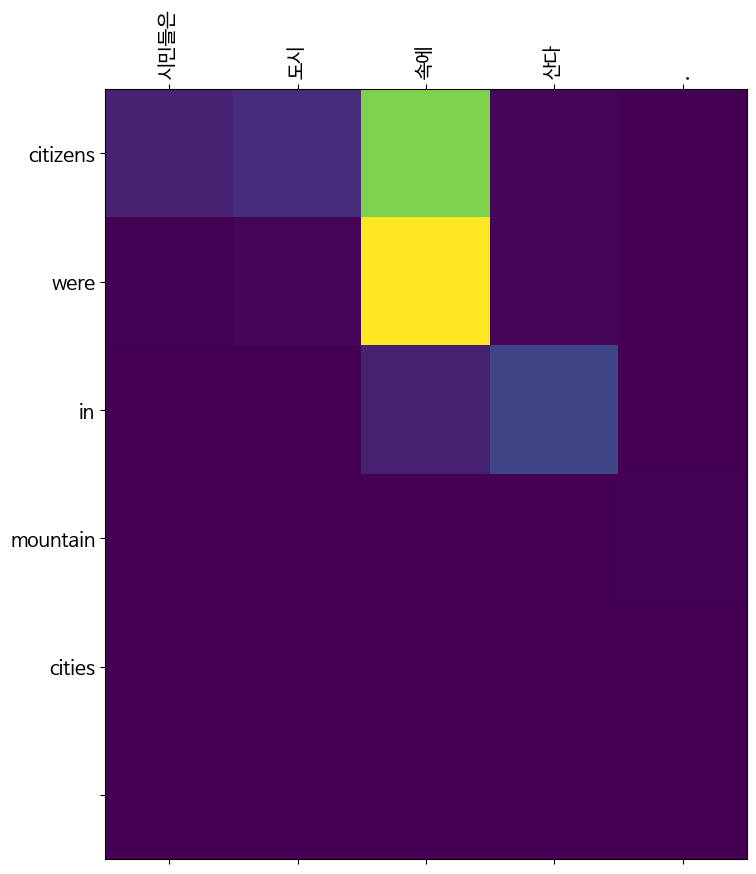

In [46]:
translate("시민들은 도시 속에 산다.", model, encoder_tokenizer, decoder_tokenizer, max_len=40)

Input: 커피는 필요 없다
Predicted translation: ['you', 'need', 'no', 'coffee', '.', '']


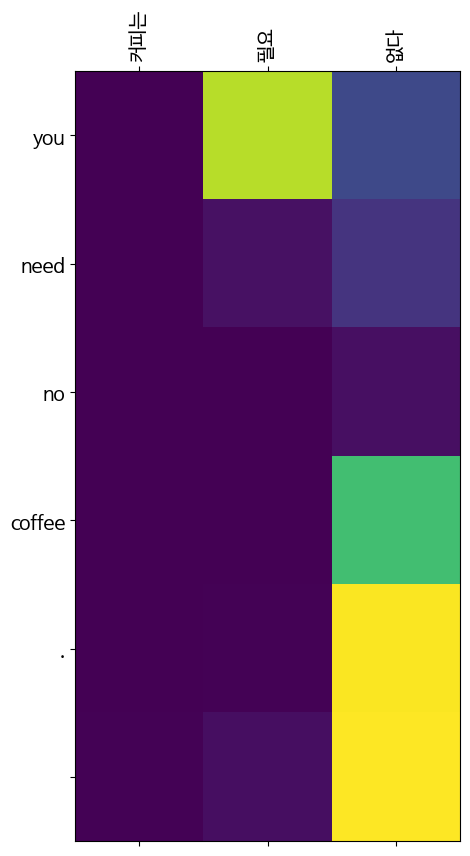

In [47]:
translate("커피는 필요 없다", model, encoder_tokenizer, decoder_tokenizer, max_len=40)

Input: 일곱 명의 사망자가 발생했다 .
Predicted translation: ['seven', 'people', 'were', 'kill', 'ed', 'and', 'seven', 'others', ',', 'the', 'associat', 'ed', 'press', 'reported', '.', '']


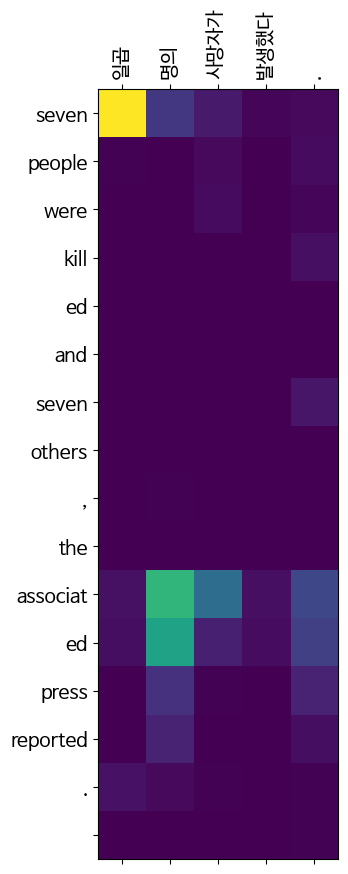

In [49]:
translate("일곱 명의 사망자가 발생했다.", model, encoder_tokenizer, decoder_tokenizer, max_len=40)

#### 회고

이번 프로젝트에서는 eval_step()을 제외하고 100% train dataset으로 학습했고, 모델이 생성한 문장을 정성적 평가로 진행.

모델이 "Obama", "President"와 같은 주요 키워드를 잡아내는 것을 확인할 수 있었으나, 문장 구조가 반복되거나 문법적으로 어색한 부분을 객관적으로 측정하기에는 한계가 있었습니다.

Loss가 낮아지는 것만으로는 실제 번역 품질의 향상을 확신하기 어렵다는 점을 느꼈고, 이번에는 시간 관계상 진행하지 못했지만, 추후에는 아래와 같은 정량적 지표를 도입하여 모델의 성능을 객관적으로 검증해보면 좋을 듯.

- BLEU : n-gram 겹침, 단어 순서, 길이 패널티
- Perplexity: 모델의 확률적 불확실성 측정
- METEOR : 동의어와 어간을 고려한 평가 지표